# Classifier-Guided Best-of-N Evaluation Analysis
**Experiment:** `20k_step_classifier_20260315_162332`

In [1]:
print('hi')

hi


In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tabulate import tabulate

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 120,
})

# ── Data loading ──

RESULTS_DIR = (
    "/global/scratch/users/yajatyadav/research/multitask_reinforcement_learning/polaris"
    "/runs/classifier_guided_jobs/20k_step_classifier_20260315_162332/job_results"
)


def load_all_results(results_dir: str = RESULTS_DIR) -> pd.DataFrame:
    """Walk the job_results directory and return a single DataFrame with columns:
    N, task, episode, episode_length, success, progress
    """
    rows = []
    for csv_path in glob.glob(os.path.join(results_dir, "job_*", "N*", "*", "eval_results.csv")):
        parts = Path(csv_path).parts
        # …/job_XXX/N<value>/TASK_NAME_timestamp/eval_results.csv
        n_folder = [p for p in parts if p.startswith("N")][0]
        n_val = int(n_folder[1:])
        task_folder = parts[-2]  # e.g. DROID-BlockStackKitchen_20260315_162436
        task_name = "-".join(task_folder.split("-")[:2]).split("_")[0]
        # More robust: take everything before the date stamp
        # e.g. "DROID-BlockStackKitchen_20260315_162436" -> "DROID-BlockStackKitchen"
        idx = task_folder.rfind("_202")
        if idx == -1:
            idx = task_folder.rfind("_202")
        task_name = task_folder[:idx] if idx != -1 else task_folder
        # Remove trailing date if double-stamped
        idx2 = task_name.rfind("_202")
        if idx2 != -1:
            task_name = task_name[:idx2]

        df = pd.read_csv(csv_path)
        df["N"] = n_val
        df["task"] = task_name
        rows.append(df)
    return pd.concat(rows, ignore_index=True)


def compute_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Group by (N, task) and compute mean/sem for success and progress."""
    def _agg(g):
        n_rollouts = len(g)
        return pd.Series({
            "n_rollouts": n_rollouts,
            "success_mean": g["success"].mean(),
            "success_sem": g["success"].std(ddof=1) / np.sqrt(n_rollouts) if n_rollouts > 1 else 0,
            "progress_mean": g["progress"].mean(),
            "progress_sem": g["progress"].std(ddof=1) / np.sqrt(n_rollouts) if n_rollouts > 1 else 0,
        })
    return df.groupby(["N", "task"]).apply(_agg).reset_index()


def compute_avg_stats(stats: pd.DataFrame) -> pd.DataFrame:
    """Average over tasks for each N (propagate uncertainty)."""
    def _agg(g):
        n_tasks = len(g)
        return pd.Series({
            "n_rollouts_total": int(g["n_rollouts"].sum()),
            "success_mean": g["success_mean"].mean(),
            "success_sem": np.sqrt((g["success_sem"] ** 2).sum()) / n_tasks,
            "progress_mean": g["progress_mean"].mean(),
            "progress_sem": np.sqrt((g["progress_sem"] ** 2).sum()) / n_tasks,
        })
    return stats.groupby("N").apply(_agg).reset_index()


# ── Plotting ──

def plot_bon_curve(stats_df: pd.DataFrame, title: str = "Best-of-N"):
    """Line plot with x=N, two lines (success, progress) with shaded error bars."""
    fig, ax = plt.subplots(figsize=(6, 4))
    ns = stats_df["N"].values

    for metric, color, label in [
        ("success", "tab:blue", "Success Rate"),
        ("progress", "tab:orange", "Progress"),
    ]:
        mean = stats_df[f"{metric}_mean"].values
        sem = stats_df[f"{metric}_sem"].values
        ax.plot(ns, mean, "o-", color=color, label=label)
        ax.fill_between(ns, mean - sem, mean + sem, alpha=0.2, color=color)

    ax.set_xlabel("N (Best-of-N)")
    ax.set_ylabel("Value")
    ax.set_title(title)
    ax.set_xticks(ns)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    fig.tight_layout()
    return fig


def print_results_table(stats: pd.DataFrame):
    """Pretty-print the per-task, per-N results table."""
    stats_sorted = stats.sort_values(["task", "N"])
    table_rows = []
    for _, r in stats_sorted.iterrows():
        table_rows.append([
            r["task"], r["N"], int(r["n_rollouts"]),
            f'{r["success_mean"]:.3f} ± {r["success_sem"]:.3f}',
            f'{r["progress_mean"]:.3f} ± {r["progress_sem"]:.3f}',
        ])
    print(tabulate(
        table_rows,
        headers=["Task", "N", "Rollouts", "Success (mean±sem)", "Progress (mean±sem)"],
        tablefmt="github",
    ))

## Load data & print results table

In [2]:
df = load_all_results()
stats = compute_stats(df)
print_results_table(stats)

| Task                    |   N |   Rollouts | Success (mean±sem)   | Progress (mean±sem)   |
|-------------------------|-----|------------|----------------------|-----------------------|
| DROID-BlockStackKitchen |   1 |         50 | 0.040 ± 0.028        | 0.486 ± 0.036         |
| DROID-BlockStackKitchen |   4 |         50 | 0.020 ± 0.020        | 0.560 ± 0.033         |
| DROID-BlockStackKitchen |  16 |         50 | 0.000 ± 0.000        | 0.509 ± 0.028         |
| DROID-BlockStackKitchen |  32 |         50 | 0.020 ± 0.020        | 0.509 ± 0.037         |
| DROID-FoodBussing       |   1 |         50 | 0.120 ± 0.046        | 0.550 ± 0.038         |
| DROID-FoodBussing       |   4 |         35 | 0.229 ± 0.072        | 0.605 ± 0.050         |
| DROID-FoodBussing       |  16 |         50 | 0.120 ± 0.046        | 0.563 ± 0.039         |
| DROID-FoodBussing       |  32 |         50 | 0.120 ± 0.046        | 0.553 ± 0.037         |
| DROID-PanClean          |   1 |         50 | 0.440 ± 0.071

## Averaged over all tasks

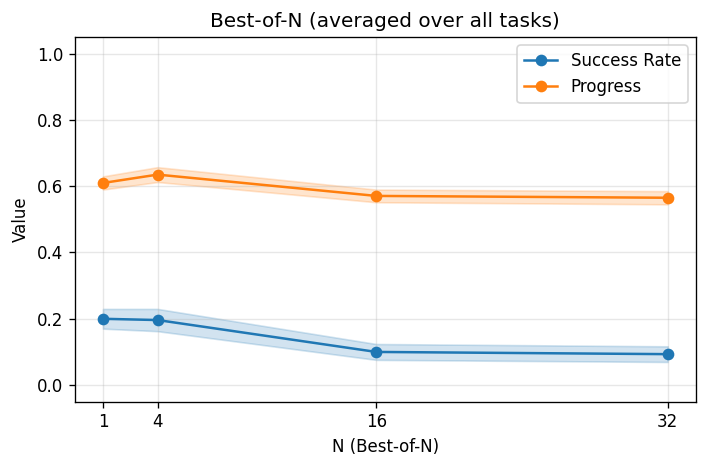

In [3]:
avg_stats = compute_avg_stats(stats)
plot_bon_curve(avg_stats, title="Best-of-N (averaged over all tasks)")
plt.show()

## Per-task plots

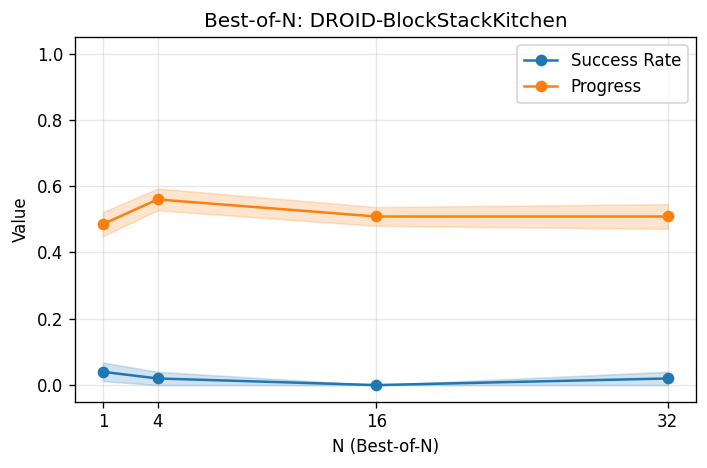

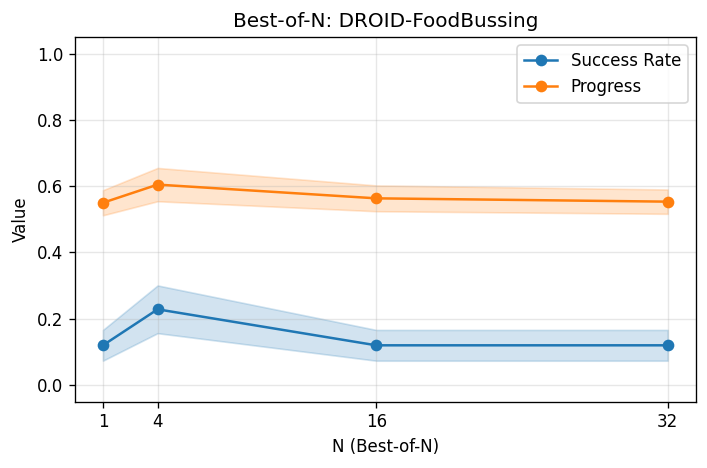

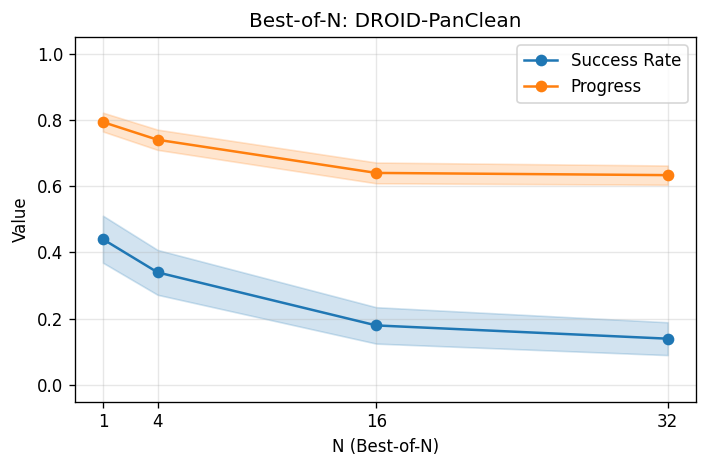

In [4]:
for task in sorted(stats["task"].unique()):
    task_stats = stats[stats["task"] == task].sort_values("N")
    plot_bon_curve(task_stats, title=f"Best-of-N: {task}")
    plt.show()

# Repeat with Autoregressive Action

| Task                    |   N |   Rollouts | Success (mean±sem)   | Progress (mean±sem)   |
|-------------------------|-----|------------|----------------------|-----------------------|
| DROID-BlockStackKitchen |   1 |         50 | 0.060 ± 0.034        | 0.540 ± 0.034         |
| DROID-BlockStackKitchen |   4 |         50 | 0.040 ± 0.028        | 0.471 ± 0.034         |
| DROID-BlockStackKitchen |  16 |         50 | 0.020 ± 0.020        | 0.457 ± 0.037         |
| DROID-BlockStackKitchen |  32 |         50 | 0.060 ± 0.034        | 0.474 ± 0.035         |
| DROID-BlockStackKitchen |  64 |         50 | 0.020 ± 0.020        | 0.423 ± 0.036         |
| DROID-FoodBussing       |   1 |         50 | 0.160 ± 0.052        | 0.570 ± 0.038         |
| DROID-FoodBussing       |   4 |         50 | 0.040 ± 0.028        | 0.490 ± 0.035         |
| DROID-FoodBussing       |  16 |         45 | 0.022 ± 0.022        | 0.441 ± 0.034         |
| DROID-FoodBussing       |  32 |         50 | 0.020 ± 0.020

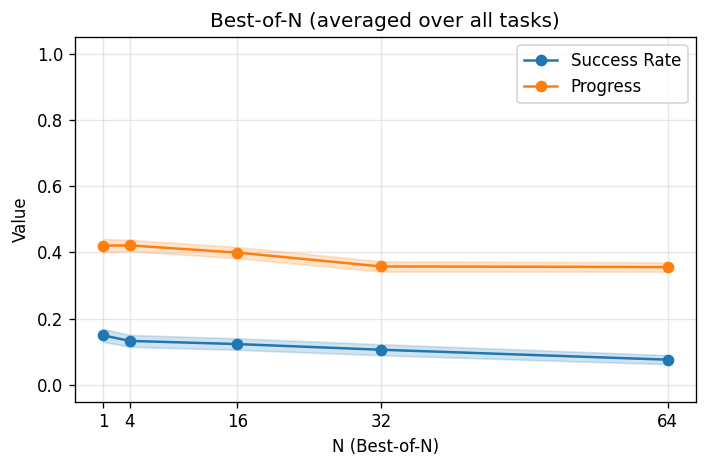

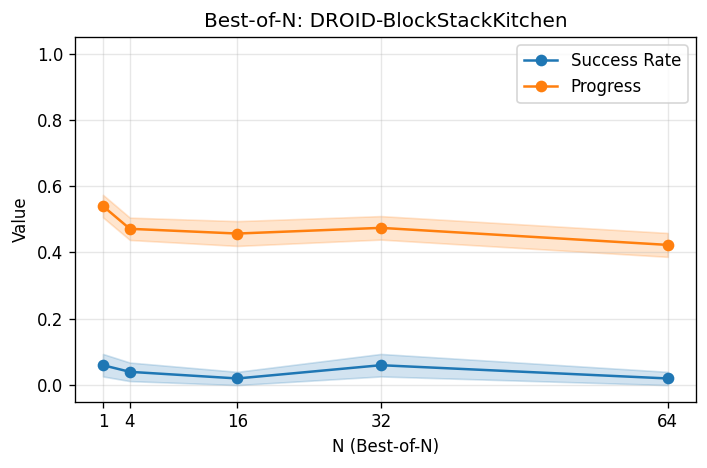

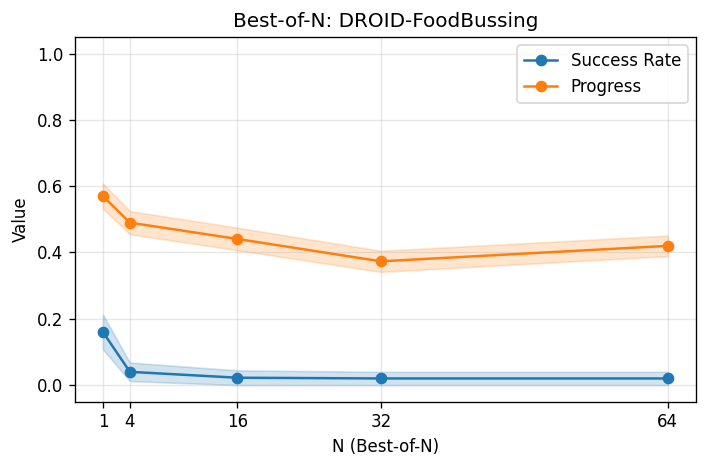

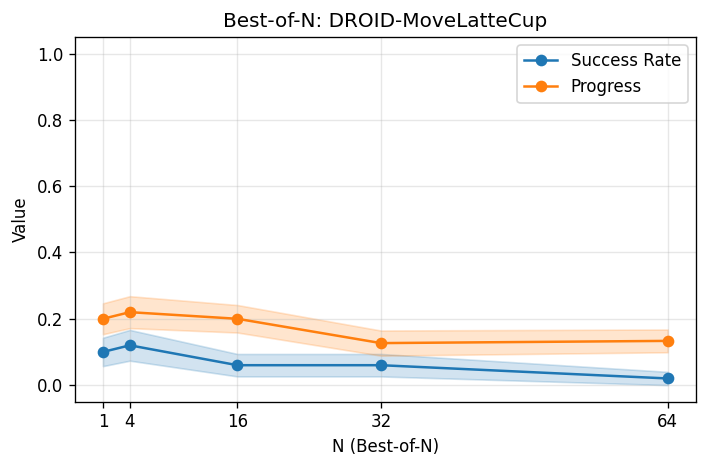

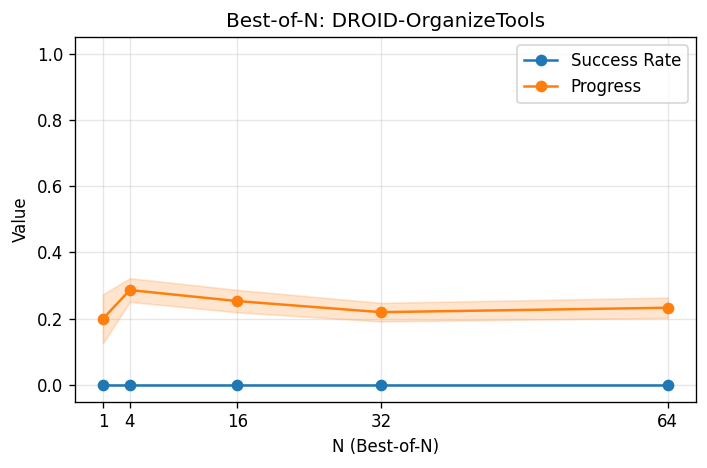

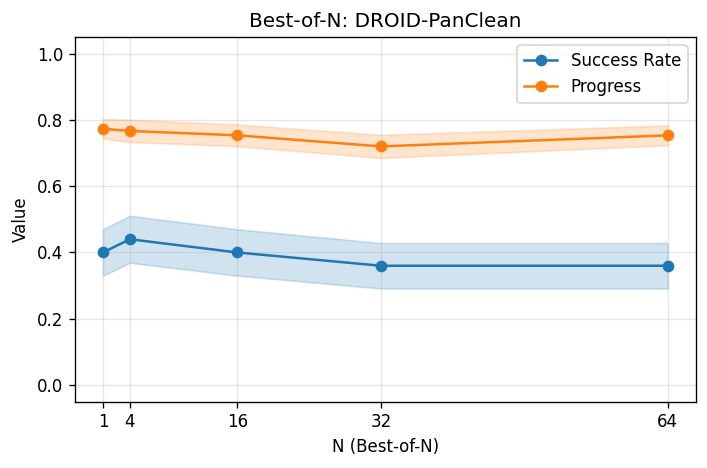

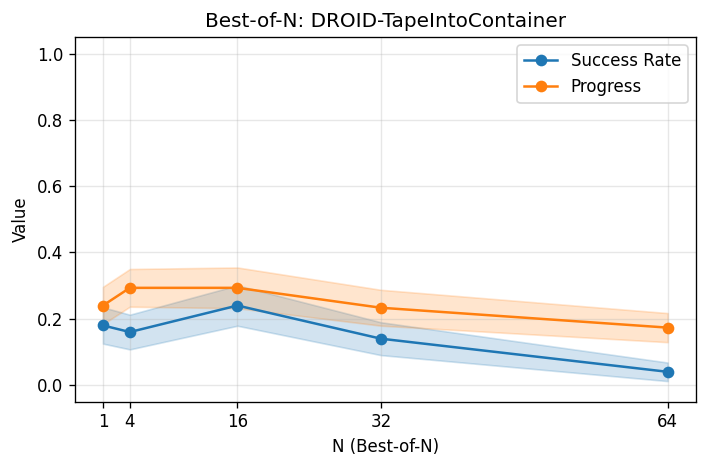

In [7]:
results_dir = (
    "/global/scratch/users/yajatyadav/research/multitask_reinforcement_learning/polaris"
    "/runs/classifier_guided_jobs/autoregaction_TRY2_classifier_step5k_20260317_172723/job_results"
)
df = load_all_results(results_dir)
stats = compute_stats(df)
print_results_table(stats)

avg_stats = compute_avg_stats(stats)
plot_bon_curve(avg_stats, title="Best-of-N (averaged over all tasks)")
plt.show()


for task in sorted(stats["task"].unique()):
    task_stats = stats[stats["task"] == task].sort_values("N")
    plot_bon_curve(task_stats, title=f"Best-of-N: {task}")
    plt.show()